## Workspace & Singularity Analysis

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

max_limit_pitch = 90.0
min_limit_pitch = -90.0
max_limit_roll = 90.0
min_limit_roll = -90.0
step = 0.5


alpha = np.arange(np.radians(min_limit_pitch), np.radians(max_limit_pitch), np.radians(step))
beta  = np.arange(np.radians(min_limit_roll), np.radians(max_limit_roll), np.radians(step))

ls = 0.08
lc = 0.075
lr = 0.115
lo = 0.025
ld = 0.09

params = (lc, ld, lo, lr)


In [ ]:

def clean(expr):
    # expr = sp.expand_trig(expr)
    # expr = sp.together(expr)
    expr = sp.cancel(expr)
    expr = sp.trigsimp(expr)
    expr = sp.simplify(expr)
    return expr
def solve_theta(alpha, beta, ls_val, params):
    lc, ld, lo, lr = params

    # rename to avoid shadowing
    A = lc*(lc*np.cos(beta) + lo*np.sin(beta))

    B = lc*(-2*lc*np.sin(beta)*np.cos(alpha)
            + 2*ld
            + 2*lo*np.cos(alpha)*np.cos(beta)
            + ls_val*np.sin(alpha)) / 2

    C = (lc**2
         - lc*ld*np.sin(beta)*np.cos(alpha)
         - 0.5*lc*ls_val*np.sin(alpha)*np.sin(beta)
         + 0.5*ld**2
         + ld*lo*np.cos(alpha)*np.cos(beta)
         + 0.5*ld*ls_val*np.sin(alpha)
         + 0.5*lo**2
         + 0.5*lo*ls_val*np.sin(alpha)*np.cos(beta)
         - 0.5*lr**2
         - 0.25*ls_val**2*np.cos(alpha)
         + 0.25*ls_val**2)

    denom = A*A + B*B

    disc = B*B*C*C - denom*(C*C - A*A)
    if disc < -1e-9:
        return None  # no real solution

    disc = max(disc, 0.0)
    root = np.sqrt(disc)

    s = (B*C - root) / denom
    c = (C - B*s) / A

    theta = np.arctan2(s, c)
    return theta
def solve_thetas(alpha, beta, ls, params):
    theta1 = solve_theta(alpha, beta, +ls, params)
    theta2 = solve_theta(alpha, beta, -ls, params)
    return theta1, theta2
def detJ_numeric(a, b, theta1, theta2):
    
    detJ_val = (
        4*lc**4*sp.sin(a)*sp.sin(theta1 - theta2)*sp.cos(b)**2 - 4*lc**4*sp.sin(a)*sp.sin(theta1 - theta2) + 4*lc**3*ld*sp.sin(a)*sp.cos(b)**2*sp.cos(theta1) 
        - 4*lc**3*ld*sp.sin(a)*sp.cos(b)**2*sp.cos(theta2) - 4*lc**3*ld*sp.sin(a)*sp.cos(theta1) + 4*lc**3*ld*sp.sin(a)*sp.cos(theta2) 
        + 8*lc**3*lo*sp.sin(a)*sp.sin(b)*sp.sin(theta1 - theta2)*sp.cos(b) - 2*lc**3*ls*sp.sin(b)*sp.sin(theta1 + theta2)*sp.cos(a) - 4*lc**3*ls*sp.sin(theta1)*sp.sin(theta2)*sp.cos(a)**2*sp.cos(b) 
        + 2*lc**3*ls*sp.cos(a)*sp.cos(b)**2*sp.cos(theta1) + 2*lc**3*ls*sp.cos(a)*sp.cos(b)**2*sp.cos(theta2) - 2*lc**3*ls*sp.cos(a)*sp.cos(theta1) 
        - 2*lc**3*ls*sp.cos(a)*sp.cos(theta2) - lc**3*ls*sp.cos(2*b - theta1)/2 + lc**3*ls*sp.cos(2*b + theta1)/2 
        - lc**3*ls*sp.cos(2*b - theta2)/2 + lc**3*ls*sp.cos(2*b + theta2)/2 + 8*lc**2*ld*lo*sp.sin(a)*sp.sin(b)*sp.cos(b)*sp.cos(theta1) 
        - 8*lc**2*ld*lo*sp.sin(a)*sp.sin(b)*sp.cos(b)*sp.cos(theta2) + 2*lc**2*ld*ls*sp.sin(b)*sp.cos(a)*sp.cos(theta1) + 2*lc**2*ld*ls*sp.sin(b)*sp.cos(a)*sp.cos(theta2) + 2*lc**2*ld*ls*sp.sin(2*b) + 4*lc**2*ld*ls*sp.sin(theta1)*sp.cos(a)**2*sp.cos(b) 
        + 4*lc**2*ld*ls*sp.sin(theta2)*sp.cos(a)**2*sp.cos(b) - 4*lc**2*lo**2*sp.sin(a)*sp.sin(theta1 - theta2)*sp.cos(b)**2 - 4*lc**2*lo*ls*sp.sin(b)*sp.sin(theta1)*sp.sin(theta2)*sp.cos(a)**2 
        + 4*lc**2*lo*ls*sp.sin(b)*sp.cos(a)*sp.cos(b)*sp.cos(theta1) + 4*lc**2*lo*ls*sp.sin(b)*sp.cos(a)*sp.cos(b)*sp.cos(theta2) + 4*lc**2*lo*ls*sp.sin(theta1)*sp.cos(b)**2 
        - 2*lc**2*lo*ls*sp.sin(theta1) + 4*lc**2*lo*ls*sp.sin(theta2)*sp.cos(b)**2 - 2*lc**2*lo*ls*sp.sin(theta2) 
        + 2*lc**2*lo*ls*sp.sin(theta1 + theta2)*sp.cos(a)*sp.cos(b) - lc**2*ls**2*sp.sin(a)*sp.sin(b)*sp.cos(theta1) + lc**2*ls**2*sp.sin(a)*sp.sin(b)*sp.cos(theta2) 
        - 2*lc**2*ls**2*sp.sin(a)*sp.sin(theta1)*sp.cos(a)*sp.cos(b) + 2*lc**2*ls**2*sp.sin(a)*sp.sin(theta2)*sp.cos(a)*sp.cos(b) - 4*lc*ld**2*ls*sp.cos(a)**2*sp.cos(b) 
        - 4*lc*ld*lo**2*sp.sin(a)*sp.cos(b)**2*sp.cos(theta1) + 4*lc*ld*lo**2*sp.sin(a)*sp.cos(b)**2*sp.cos(theta2) + 4*lc*ld*lo*ls*sp.sin(b)*sp.sin(theta1)*sp.cos(a)**2 
        + 4*lc*ld*lo*ls*sp.sin(b)*sp.sin(theta2)*sp.cos(a)**2 - 2*lc*ld*lo*ls*sp.cos(a)*sp.cos(b)*sp.cos(theta1) - 2*lc*ld*lo*ls*sp.cos(a)*sp.cos(b)*sp.cos(theta2) - 8*lc*ld*lo*ls*sp.cos(b)**2 + 4*lc*ld*lo*ls 
        - 2*lc*lo**2*ls*sp.cos(a)*sp.cos(b)**2*sp.cos(theta1) - 2*lc*lo**2*ls*sp.cos(a)*sp.cos(b)**2*sp.cos(theta2) + lc*lo**2*ls*sp.cos(2*b - theta1)/2 - lc*lo**2*ls*sp.cos(2*b + theta1)/2 
        + lc*lo**2*ls*sp.cos(2*b - theta2)/2 - lc*lo**2*ls*sp.cos(2*b + theta2)/2 - 2*lc*lo*ls**2*sp.sin(a)*sp.sin(b)*sp.sin(theta1)*sp.cos(a)  + 2*lc*lo*ls**2*sp.sin(a)*sp.sin(b)*sp.sin(theta2)*sp.cos(a) + lc*lo*ls**2*sp.sin(a)*sp.cos(b)*sp.cos(theta1) 
        - lc*lo*ls**2*sp.sin(a)*sp.cos(b)*sp.cos(theta2) - lc*ls**3*sp.cos(a)**2*sp.cos(b) + lc*ls**3*sp.cos(b) 
        - 4*ld**2*lo*ls*sp.sin(b)*sp.cos(a)**2 - 2*ld*lo**2*ls*sp.sin(2*b) - lo*ls**3*sp.sin(b)*sp.cos(a)**2 + lo*ls**3*sp.sin(b)
        )
    return detJ_val

detJ_map = np.full((len(alpha), len(beta)), np.nan)

for i, a in enumerate(alpha):
    for j, b in enumerate(beta):
        sol = solve_thetas(a, b, ls, params)
        if sol[0] is None or sol[1] is None:
            continue
        theta1, theta2 = sol
        # print(np.degrees(a), np.degrees(b) , np.degrees(theta1), np.degrees(theta2)) 
        detJ_map[i, j] = detJ_numeric(a, b, theta1, theta2)
        

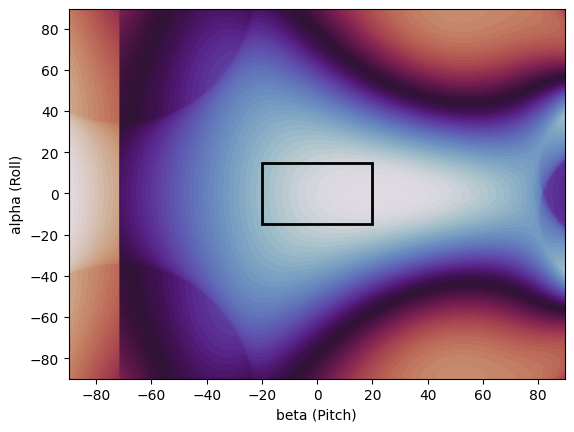

In [ ]:
A, B = np.meshgrid(np.degrees(beta), np.degrees(alpha))
signed_log = np.sign(detJ_map) * np.log10(1 + np.abs(detJ_map))

target_pitch_min, target_pitch_max = -20.0, 20.0
target_roll_min, target_roll_max = -15.0, 15.0

fig, ax = plt.subplots()

cf = ax.contourf(A, B, signed_log, levels=100, cmap="twilight")
# ax.contour(A, B, detJ_map, levels=[0], colors='black')

rect = patches.Rectangle(
    (target_pitch_min, target_roll_min),
    target_pitch_max - target_pitch_min,
    target_roll_max - target_roll_min,
    linewidth=2,
    edgecolor='black',
    facecolor='none'
)

ax.add_patch(rect)
ax.set_xlim(A.min(), A.max())
ax.set_ylim(B.min(), B.max())

ax.set_xlabel("beta (Pitch)")
ax.set_ylabel("alpha (Roll)")

plt.show()



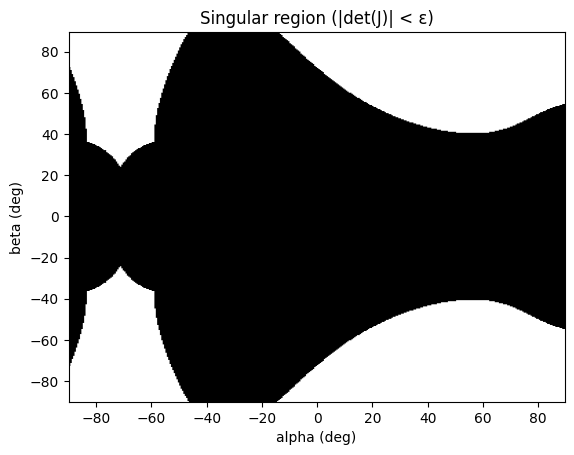

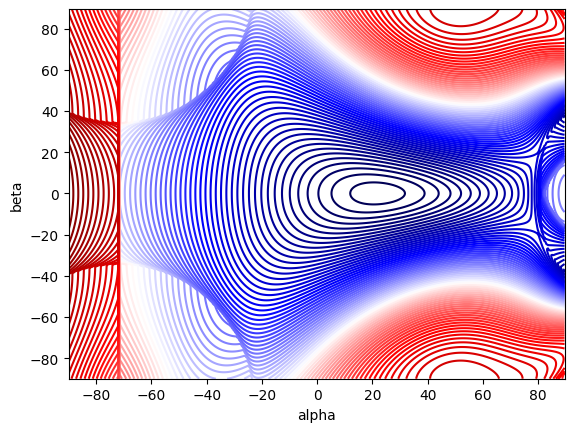

In [ ]:

eps = 1e-4
singularity_mask = np.abs(detJ_map) < eps

plt.imshow(
    singularity_mask,
    extent=[A.min(), A.max(), B.min(), B.max()],
    origin='lower',
    aspect='auto',
    cmap='gray'
)
plt.xlabel("alpha (deg)")
plt.ylabel("beta (deg)")
plt.title("Singular region (|det(J)| < ε)")
plt.show()


plt.contour(A, B, detJ_map, cmap='seismic', levels=100)
plt.xlabel("alpha")
plt.ylabel("beta")
# plt.colorbar(label="det(J)")
plt.show()
